# Phrase-Based Statistical Machine Translation (PBSMT): Version 4
## Myanmar (Burmese) Language: Grapheme - Phoneme Translation

## Setup

In [1]:
from pathlib import Path
from IPython.display import Image

In [2]:
ROOT = Path("..").resolve()

DATA_ROOT = ROOT / "data"
DATA_DIR = DATA_ROOT / "cleaned"

BASELINE2_DIR = ROOT / "baseline2"

PAIRS = [
    ("train", "my", "ph"),
    ("dev", "my", "ph"),
    ("test", "my", "ph"),
]

## Run 5: Results Revisit

Run 5 is named as Run 2 under `baseline2/`.

In [3]:
!ls {BASELINE2_DIR}/my-ph/model -F --color=auto

aligned.1.grow-diag-final-and  lex.1.f2e
extract.1.inv.sorted.gz        moses.ini.1
extract.1.o.sorted.gz          moses.ini.2
extract.1.sorted.gz            phrase-table.1.gz
lex.1.e2f                      reordering-table.1.wbe-msd-bidirectional-fe.gz


In [4]:
!cat {BASELINE2_DIR}/my-ph/model/moses.ini.2

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/model/phrase-table.1 input-factor=0 output-factor=0
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/model/reordering-table.1.wbe-msd-bidirectional-fe.gz
Distortion
KENLM name=LM0 factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/lm/myg2p-data.binlm.2 order=3

# dense weights for feature functions
[weight]
# The default weights are NOT optimized for translation quality. You MUST tune the weights.
# Documentation

In [5]:
!ls {BASELINE2_DIR}/my-ph/tuning -F --color=auto

filtered.1/           moses.ini.1        moses.tuned.ini.2
moses.filtered.ini.1  moses.ini.2        tmp.1/
moses.filtered.ini.2  moses.tuned.ini.1  tmp.2/


In [6]:
!cat {BASELINE2_DIR}/my-ph/tuning/moses.filtered.ini.2

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/tuning/filtered.1/phrase-table.0-0.1.1.gz input-factor=0 output-factor=0 
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/tuning/filtered.1/reordering-table.1.wbe-msd-bidirectional-fe.0-0.1 
Distortion
KENLM name=LM0 factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/lm/myg2p-data.binlm.2 order=3

# dense weights for feature functions
[weight]
# The default weights are NOT optimized for translation quality. You 

In [7]:
!cat {BASELINE2_DIR}/my-ph/tuning/moses.tuned.ini.2

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/model/phrase-table.1 input-factor=0 output-factor=0
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/model/reordering-table.1.wbe-msd-bidirectional-fe.gz
Distortion
KENLM name=LM0 factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/lm/myg2p-data.binlm.2 order=3

# core weights
[weight]
LexicalReordering0= 0.20999 0.0787821 0.0390794 0.00688204 0.176418 0.0973198
Distortion0= 0.0029959
LM0= 0.0480646
WordPenalty0= 

## More Tuning Options

### Distortion Limit

It is a decoder parameter that caps how far target phrases may move left or right during translation search. The default is 6. It is stored in moses.ini and used only in the tuning and evaluation phases.

Lower values keep word order closer to the source; higher values allow more reordering. Distortion limit is left unchanged in this experiment.

### Max-Phrase Length

It is a parameter that limits the phrase table to pairs with at most N tokens on each side (source and target). The default is 5.

Lower values restrict the table to shorter phrase pairs only. For word-level grapheme–phoneme data, max-phrase length is set to 3 in this experiment.

## Run 6

### Configurations

3 config files (`config.baseline2` and two generated config files) are edited.

```
max-phrase-length = 5 # change this
max-phrase-length = 3 # to this
```

In [8]:
!grep "max-phrase-length" {ROOT}/config.baseline2
!grep "max-phrase-length" {BASELINE2_DIR}/my-ph/config.baseline2.my-ph
!grep "max-phrase-length" {BASELINE2_DIR}/ph-my/config.baseline2.ph-my

max-phrase-length = 3 # -- EDIT HERE --
max-phrase-length = 3 # -- EDIT HERE --
max-phrase-length = 3 # -- EDIT HERE --


### Machine Translation

In [9]:
%cd {ROOT}/baseline2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2


In [10]:
!time perl {ROOT}/run-baseline.pl

my-ph-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/config.baseline2.my-ph
ph-my-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/config.baseline2.ph-my

real	15m56.293s
user	0m16.858s
sys	0m2.736s


### Results

Run 6 is named as Run 3 under `baseline2/`.

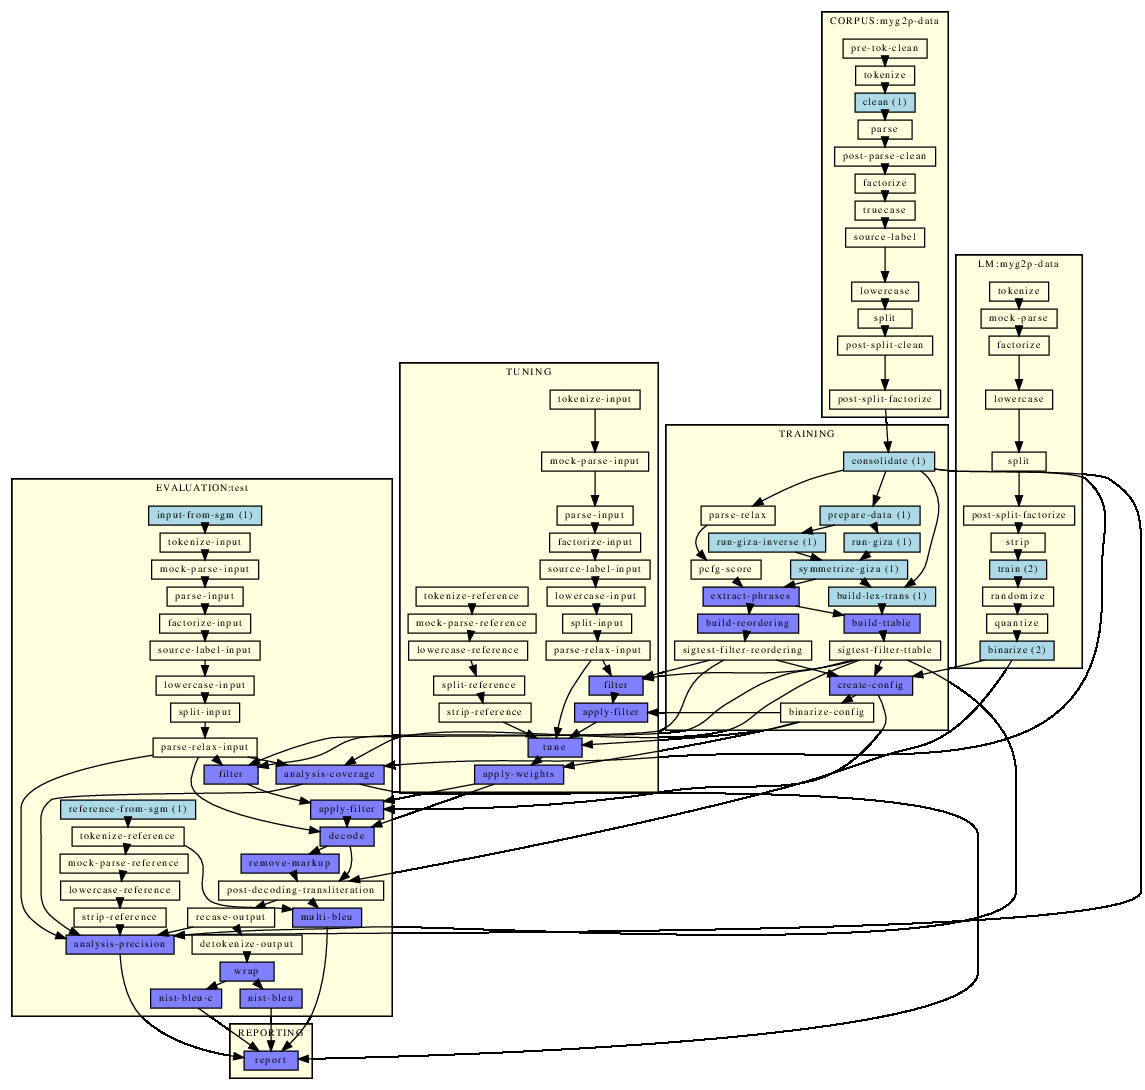

In [11]:
# check graphs
Image(filename=f'{ROOT}/baseline2/my-ph/steps/3/graph.3.png', width=800)

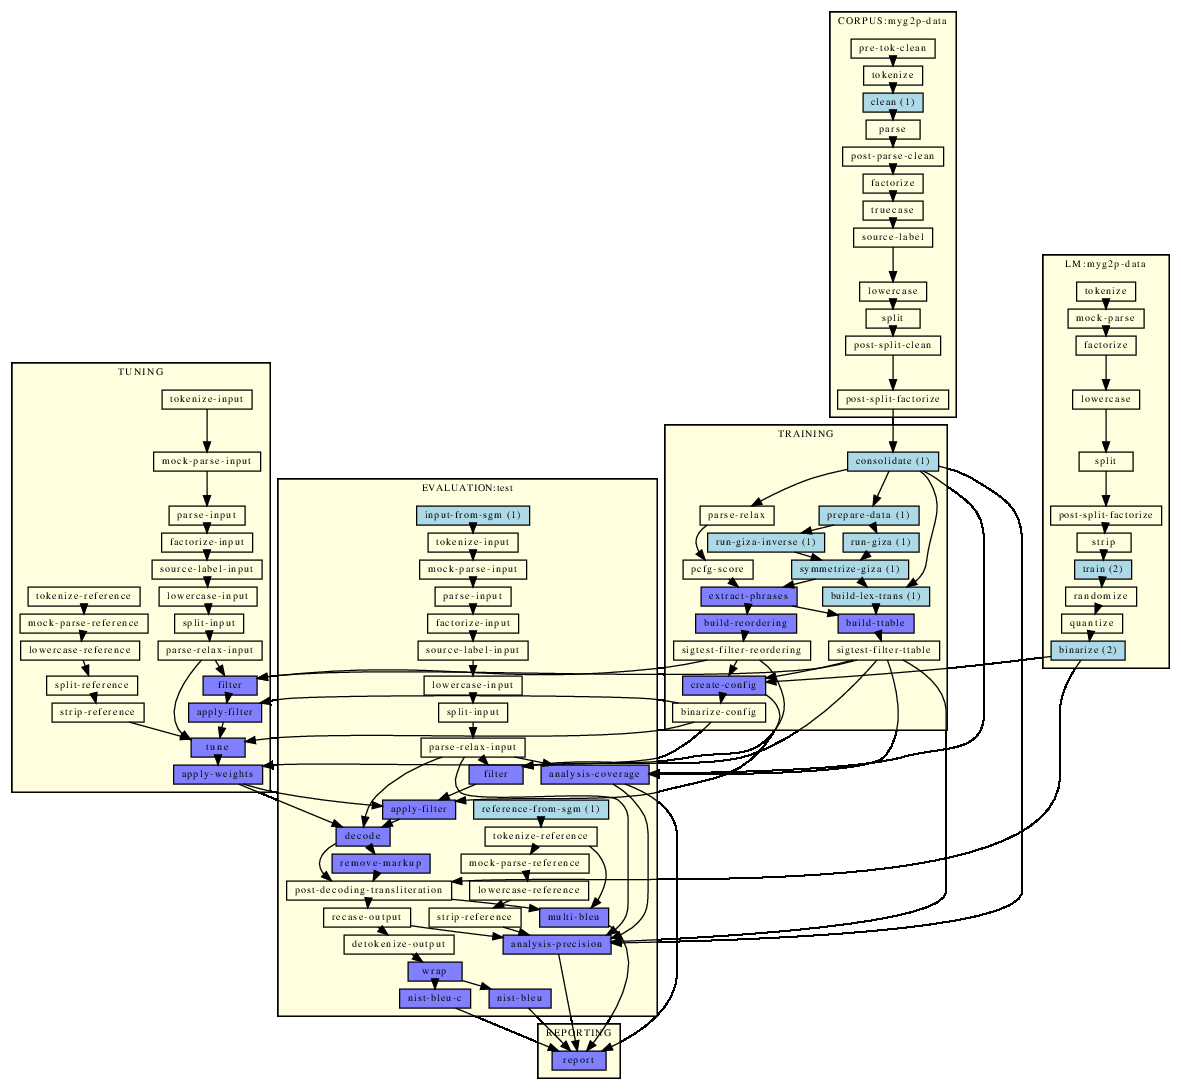

In [12]:
Image(filename=f'{ROOT}/baseline2/ph-my/steps/3/graph.3.png', width=800)

In [13]:
# check errors
!cat {ROOT}/baseline2/my-ph/steps/3/EVALUATION_test_nist-bleu.3.STDERR
!echo
!cat {ROOT}/baseline2/my-ph/steps/3/EVALUATION_test_nist-bleu-c.3.STDERR
!echo
!cat {ROOT}/baseline2/ph-my/steps/3/EVALUATION_test_nist-bleu-c.3.STDERR
!echo
!cat {ROOT}/baseline2/ph-my/steps/3/EVALUATION_test_nist-bleu.3.STDERR

### Multi-BLEU Score

In [14]:
!find {ROOT}/baseline2/my-ph/evaluation -type f -name "*bleu.3"
!find {ROOT}/baseline2/ph-my/evaluation -type f -name "*bleu.3"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.multi-bleu.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.multi-bleu.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.nist-bleu.3


In [15]:
%cd {ROOT}/baseline2/my-ph/evaluation
!cat test.multi-bleu.3

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.46, 85.1/72.5/64.2/58.8 (BP=1.000, ratio=1.000, hyp_len=8051, ref_len=8048)


In [16]:
%cd {ROOT}/baseline2/ph-my/evaluation
!cat test.multi-bleu.3

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.31, 87.9/79.6/75.4/71.4 (BP=1.000, ratio=1.000, hyp_len=8045, ref_len=8048)


## More Tuning Options

### LM Pruning

KenLM has `--prune` setting that drops low-count n-grams when the language model is built. The current default-style setup uses '0 0 1' for order 3, which removes singleton trigrams.

This experiment uses '0 0 0' so trigrams are not pruned so that rare phoneme sequences in the target language model remain available during decoding, which may improve word choice for low-frequency mappings without changing LM order or the phrase table.

## Run 7

### Configurations

3 config files (`config.baseline2` and two generated config files) are edited.

```
settings = "--prune '0 0 1' -T $working-dir/lm -S 20% --discount_fallback" # change this
settings = "--prune '0 0 0' -T $working-dir/lm -S 20% --discount_fallback" # to this
```

In [17]:
!grep "settings = \"--prune" {ROOT}/config.baseline2
!grep "settings = \"--prune" {BASELINE2_DIR}/my-ph/config.baseline2.my-ph
!grep "settings = \"--prune" {BASELINE2_DIR}/ph-my/config.baseline2.ph-my

settings = "--prune '0 0 0' -T $working-dir/lm -S 20% --discount_fallback" # -- EDIT HERE --
settings = "--prune '0 0 0' -T $working-dir/lm -S 20% --discount_fallback" # -- EDIT HERE --
settings = "--prune '0 0 0' -T $working-dir/lm -S 20% --discount_fallback" # -- EDIT HERE --


### Machine Translation

In [18]:
%cd {ROOT}/baseline2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2


In [19]:
!time perl {ROOT}/run-baseline.pl

my-ph-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/config.baseline2.my-ph
ph-my-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/config.baseline2.ph-my

real	9m8.431s
user	0m15.224s
sys	0m2.237s


### Results

Run 7 is named as Run 4 under `baseline2/`.

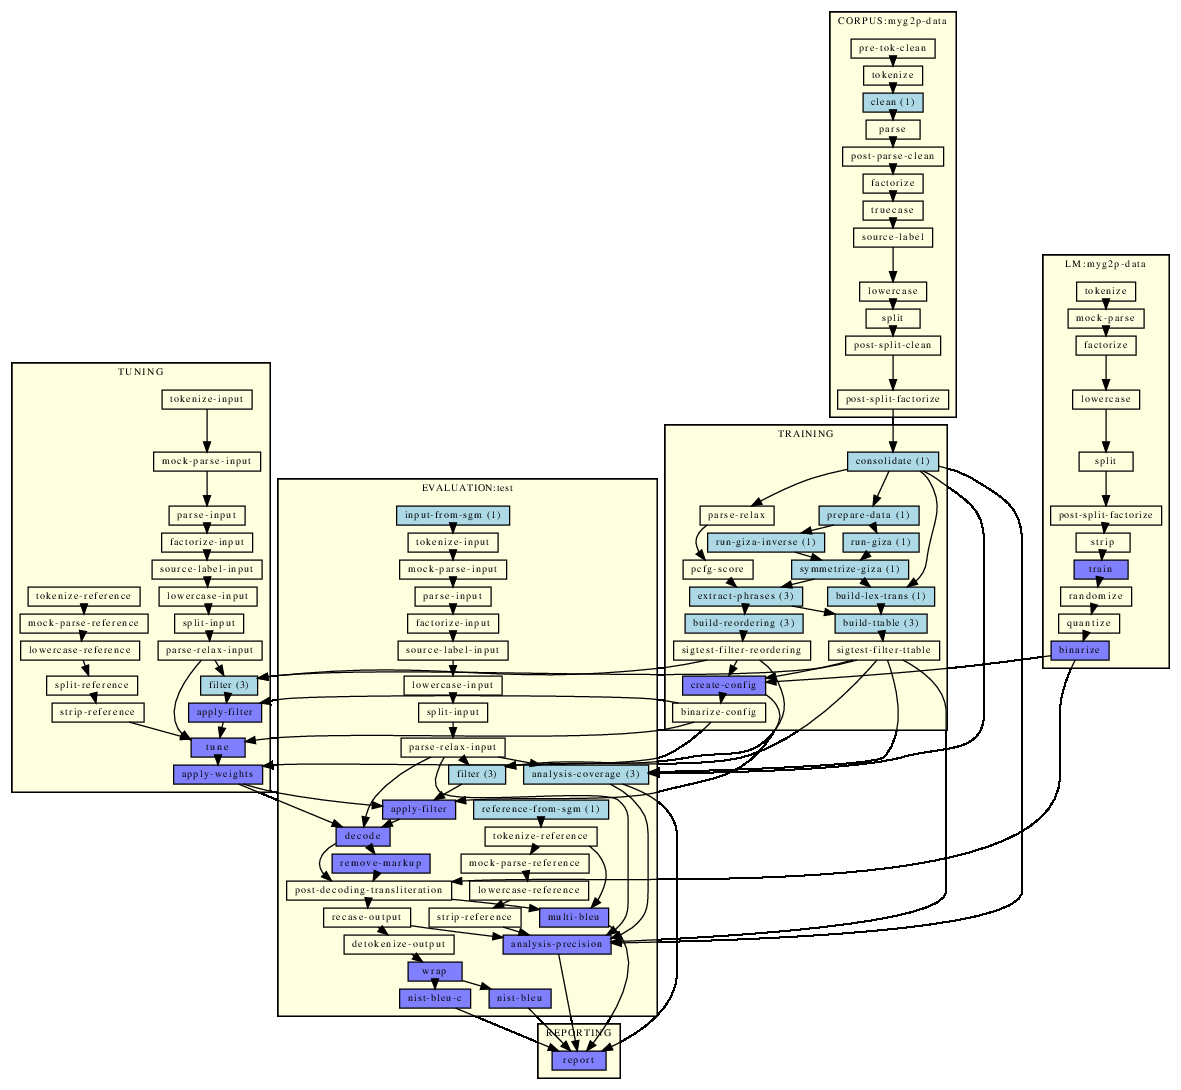

In [20]:
# check graphs
Image(filename=f'{ROOT}/baseline2/my-ph/steps/4/graph.4.png', width=800)

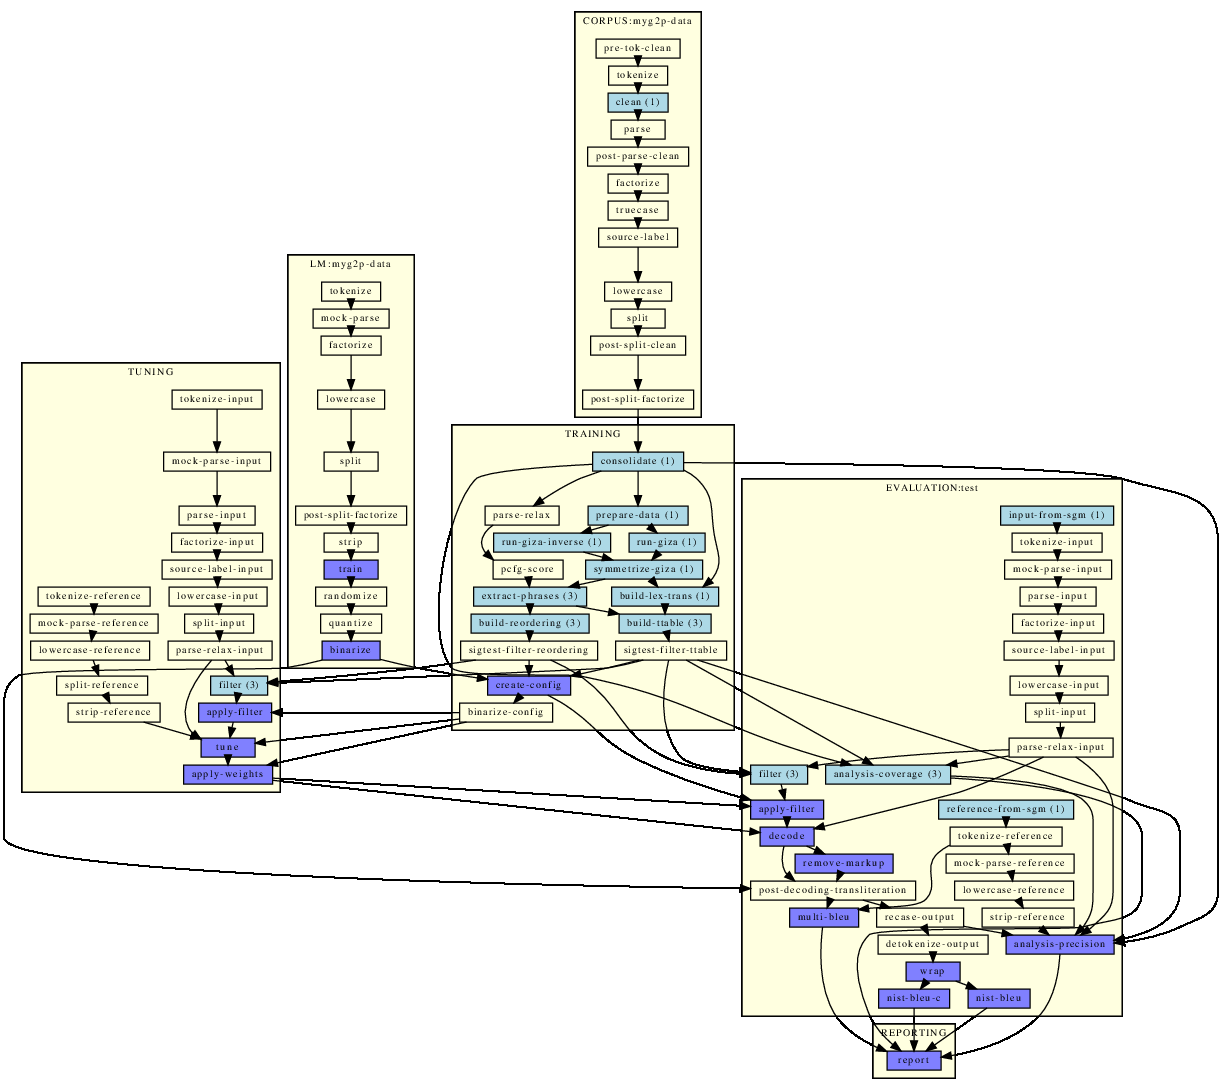

In [21]:
Image(filename=f'{ROOT}/baseline2/ph-my/steps/4/graph.4.png', width=800)

In [22]:
# check errors
!cat {ROOT}/baseline2/my-ph/steps/4/EVALUATION_test_nist-bleu.4.STDERR
!echo
!cat {ROOT}/baseline2/my-ph/steps/4/EVALUATION_test_nist-bleu-c.4.STDERR
!echo
!cat {ROOT}/baseline2/ph-my/steps/4/EVALUATION_test_nist-bleu-c.4.STDERR
!echo
!cat {ROOT}/baseline2/ph-my/steps/4/EVALUATION_test_nist-bleu.4.STDERR

### Multi-BLEU Score

In [23]:
!find {ROOT}/baseline2/my-ph/evaluation -type f -name "*bleu.4"
!find {ROOT}/baseline2/ph-my/evaluation -type f -name "*bleu.4"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.multi-bleu.4
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu.4
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.multi-bleu.4
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.nist-bleu.4


In [24]:
%cd {ROOT}/baseline2/my-ph/evaluation
!cat test.multi-bleu.4

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.88, 85.3/72.8/65.0/59.1 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [25]:
%cd {ROOT}/baseline2/ph-my/evaluation
!cat test.multi-bleu.4

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.30, 87.7/79.3/75.4/71.8 (BP=1.000, ratio=1.000, hyp_len=8045, ref_len=8048)


## More Tuning Options

### MGIZA

Moses uses word alignments to learn which source and target words correspond before building the phrase table. The default tool for that step is classic GIZA++, which runs single-threaded.

MGIZA is a multi-threaded version of the same alignment models. It estimates the same kind of word alignments but can run faster on multi-core machines and sometimes yields slightly different alignments because of how the data is split and merged across threads.

This experiment switches alignment from GIZA++ to MGIZA so phrase pairs are extracted from MGIZA alignments instead. Better alignments can improve phrase-table quality and translation accuracy; the decoder, language model, and tuning process are unchanged.

## Run 8

### Add Missing File to GIZA++

The **`giza-pp/GIZA++-v2/`** folder expects the following executables:

- `mgizapp`
- `sntcooc`
- `merge_alignment.py`.

These files are located in `mgiza/`, which is a custom installation directory.

### Configurations

3 config files (`config.baseline2` and two generated config files) are edited.

```
training-options = "-mgiza -mgiza-cpus 8" # uncomment this
```

In [26]:
!grep "training-options" {ROOT}/config.baseline2
!echo
!grep "training-options" {BASELINE2_DIR}/my-ph/config.baseline2.my-ph
!echo
!grep "training-options" {BASELINE2_DIR}/ph-my/config.baseline2.ph-my

#training-options = "-sort-parallel 8 -cores 8"
training-options = "-mgiza -mgiza-cpus 8" # -- EDIT HERE --
#training-options = "-cores 8"
#berkeley-training-options = "-Main.iters 5 5 -EMWordAligner.numThreads 8"

#training-options = "-sort-parallel 8 -cores 8"
training-options = "-mgiza -mgiza-cpus 8" # -- EDIT HERE --
#training-options = "-cores 8"
#berkeley-training-options = "-Main.iters 5 5 -EMWordAligner.numThreads 8"

#training-options = "-sort-parallel 8 -cores 8"
training-options = "-mgiza -mgiza-cpus 8" # -- EDIT HERE --
#training-options = "-cores 8"
#berkeley-training-options = "-Main.iters 5 5 -EMWordAligner.numThreads 8"


### Machine Translation

In [27]:
%cd {ROOT}/baseline2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2


In [28]:
!time perl {ROOT}/run-baseline.pl

my-ph-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/config.baseline2.my-ph
ph-my-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/config.baseline2.ph-my

real	12m21.974s
user	0m21.897s
sys	0m3.127s


### Results

Run 8 is named as Run 5 under `baseline2/`.

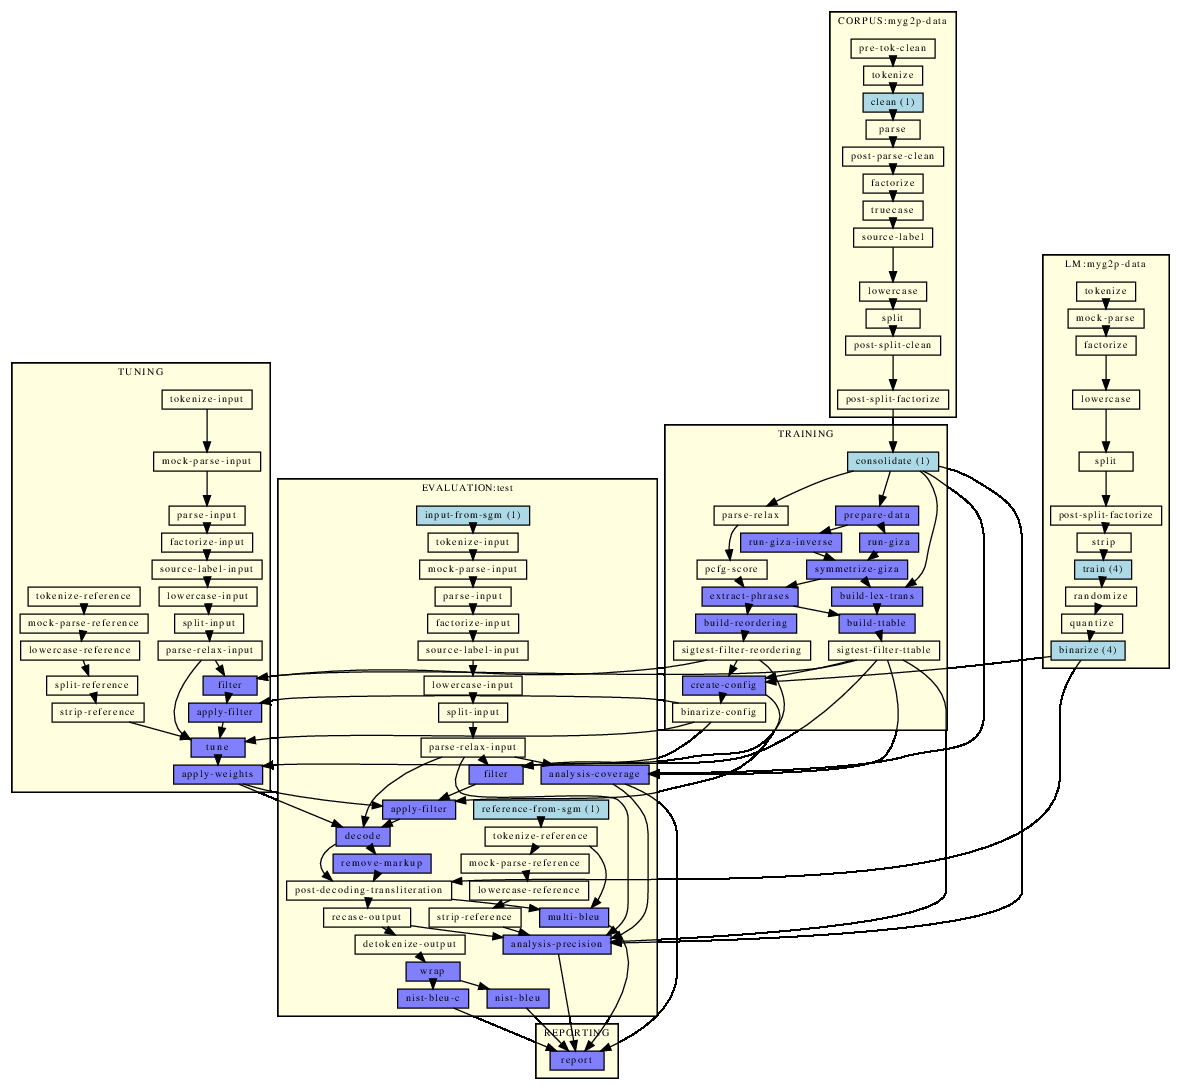

In [29]:
# check graphs
Image(filename=f'{ROOT}/baseline2/my-ph/steps/5/graph.5.png', width=800)

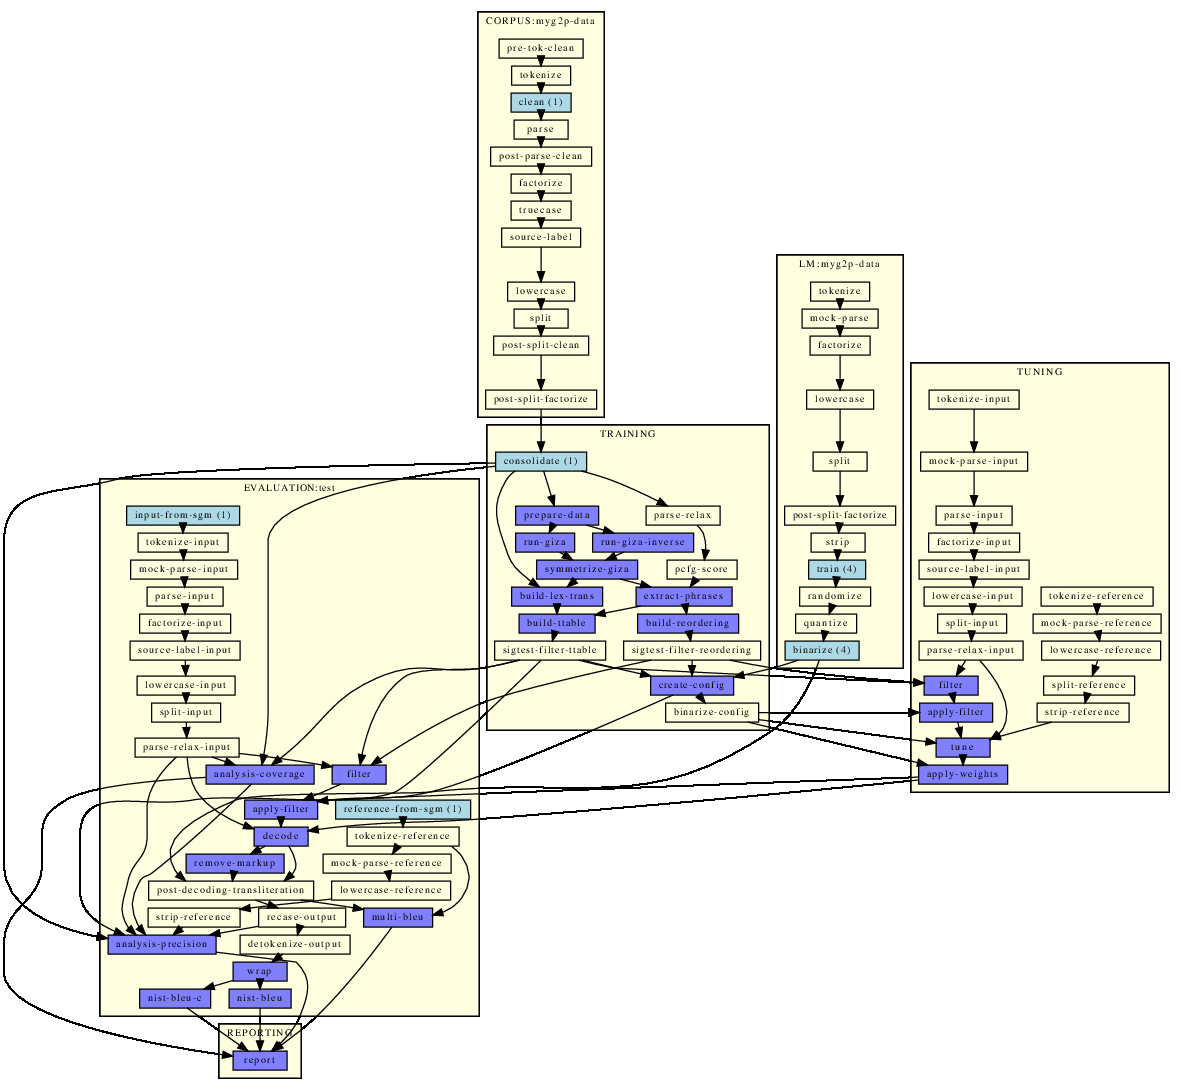

In [30]:
Image(filename=f'{ROOT}/baseline2/ph-my/steps/5/graph.5.png', width=800)

In [31]:
# check errors
!cat {ROOT}/baseline2/my-ph/steps/5/EVALUATION_test_nist-bleu.5.STDERR
!echo
!cat {ROOT}/baseline2/my-ph/steps/5/EVALUATION_test_nist-bleu-c.5.STDERR
!echo
!cat {ROOT}/baseline2/ph-my/steps/5/EVALUATION_test_nist-bleu-c.5.STDERR
!echo
!cat {ROOT}/baseline2/ph-my/steps/5/EVALUATION_test_nist-bleu.5.STDERR

### Multi-BLEU Score

In [32]:
!find {ROOT}/baseline2/my-ph/evaluation -type f -name "*bleu.5"
!find {ROOT}/baseline2/ph-my/evaluation -type f -name "*bleu.5"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu.5
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.multi-bleu.5
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.nist-bleu.5
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.multi-bleu.5


In [33]:
%cd {ROOT}/baseline2/my-ph/evaluation
!cat test.multi-bleu.5

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.71, 85.1/72.7/65.0/58.7 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [34]:
%cd {ROOT}/baseline2/ph-my/evaluation
!cat test.multi-bleu.5

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.41, 87.8/79.5/75.5/71.8 (BP=1.000, ratio=1.000, hyp_len=8045, ref_len=8048)
